# Gated Attention Fusion + XGBoost â€” IEEE-CIS Fraud Detection

**Architecture:** `architecture_justification_v2.md` Â§4.6 (Gated Attention Fusion) + Â§4.7 (XGBoost Meta-Learner)

Combines embeddings from three trained models:
- **TCN** (Keras/TF) â†’ 64-d temporal embedding
- **GAT** (PyTorch/DGL) â†’ 64-d relational embedding
- **CaT-GNN** (PyTorch/DGL) â†’ 64-d causal embedding

Fusion pipeline:
```
TCN(64) + GAT(64) + CaT-GNN(64)
   â†’ GatedFusion â†’ fused(64)
   â†’ [fused(64) || tabular(263)] â†’ XGBoost â†’ fraud probability
```

In [1]:
rm -rf /kaggle/working/*

In [2]:
!pip install dgl -f https://data.dgl.ai/wheels/torch-2.1/cu121/repo.html -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 483.2/483.2 MB 3.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.2/797.2 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 92.8 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 71.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 35.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 15.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 8.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━

In [3]:
%pip install numpy pandas scikit-learn matplotlib seaborn tensorflow keras-tcn scipy tqdm

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TensorFlow warnings
# os.environ['CUDA_VISIBLE_DEVICES'] = ''   # Disable GPU before importing TF

import numpy as np
import pandas as pd
import pickle, json, gc, time, datetime, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tcn import TCN

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import dgl
from dgl.nn import GATConv
from dgl.dataloading import MultiLayerFullNeighborSampler
from dgl.dataloading import DataLoader as DGLDataLoader

import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'TF: {tf.__version__} | PyTorch: {torch.__version__} | DGL: {dgl.__version__}')
# print('NOTE: TensorFlow set to CPU mode (CUDA_VISIBLE_DEVICES=""), PyTorch uses GPU if available')
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

# ── Workaround: Disable GPU for TCN (cuDNN version mismatch on Kaggle) ────────
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TensorFlow warnings
tf.config.set_visible_devices([], 'GPU')  # Use CPU for stability
print('TensorFlow: GPU disabled, using CPU for TCN embedding extraction')

2026-04-29 12:45:58.849159: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777466759.079348      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777466759.145425      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777466759.689628      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777466759.689664      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777466759.689667      57 computation_placer.cc:177] computation placer alr

Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)
Device: cuda
TF: 2.19.0 | PyTorch: 2.4.0+cu121 | DGL: 2.4.0+cu121
TensorFlow: GPU disabled, using CPU for TCN embedding extraction


In [5]:
# â”€â”€ Paths â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
DATA_DIR            = '/kaggle/input/competitions/ieee-fraud-detection'
DATA_DIR            = '/kaggle/input/competitions/ieee-fraud-detection'
TCN_WEIGHTS_PATH    = '/kaggle/input/datasets/jenishsorathiya/tcn-final-model/tcn_results/models/tcn_fraud_best_model.weights.h5'
TCN_SCALER_PATH     = '/kaggle/input/datasets/jenishsorathiya/tcn-final-model/tcn_results/models/tcn_scaler.pkl'
GAT_WEIGHTS_PATH    = '/kaggle/input/datasets/jenishsorathiya/gat-final-model/gat_results/models/gat_best.pt'
CATGNN_WEIGHTS_PATH = '/kaggle/input/datasets/jenishsorathiya/catgnn-final-model/catgnn_results/models/catgnn_best.pt'
SAVE_DIR            = '/kaggle/working/fusion_results'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(os.path.join(SAVE_DIR, 'models'), exist_ok=True)

# â”€â”€ Graph config (GTAN methodology) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
GRAPH_K_NEIGHBORS = 3
MAX_GROUP_SIZE    = 5000

# â”€â”€ TCN config (must match experiment_tcn exactly) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
SEQUENCE_LENGTH = 20
TCN_FILTERS     = 128
KERNEL_SIZE     = 3
DILATIONS       = [1, 2, 4, 8]
DROPOUT_RATE    = 0.2
DENSE_UNITS     = [128, 64, 32]

# â”€â”€ Model dims â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
HIDDEN_DIM = 64
NUM_HEADS  = 4
FEAT_DROP  = 0.3
ATTN_DROP  = 0.3

# â”€â”€ Fusion training â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
FUSION_LR     = 1e-3
FUSION_EPOCHS = 100
FUSION_BATCH  = 1024

print('Configuration loaded.')

Configuration loaded.


In [6]:
%%time
X_train  = pd.read_csv(f'{DATA_DIR}/train_transaction.csv')
X_test   = pd.read_csv(f'{DATA_DIR}/test_transaction.csv')
train_id = pd.read_csv(f'{DATA_DIR}/train_identity.csv')
test_id  = pd.read_csv(f'{DATA_DIR}/test_identity.csv')

for df in [train_id, test_id, X_train, X_test]:
    df.columns = [c.replace('-', '_') if c.startswith('id') else c for c in df.columns]

X_train = X_train.merge(train_id, on='TransactionID', how='left')
X_test  = X_test.merge(test_id,  on='TransactionID', how='left')

y_train = X_train['isFraud'].copy()
del X_train['isFraud']
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

print(f'Train: {X_train.shape},  Test: {X_test.shape}')
print(f'Fraud rate: {y_train.mean()*100:.2f}%')

Train: (590540, 433),  Test: (506691, 433)
Fraud rate: 3.50%
CPU times: user 33.8 s, sys: 13.3 s, total: 47.1 s
Wall time: 53.2 s


In [7]:
V_COLS  = [1,3,4,6,8,11,13,14,17,20,23,26,27,30]
V_COLS += [36,37,40,41,44,47,48,54,56,59,62,65,67,68,70]
V_COLS += [76,78,80,82,86,88,89,91]
V_COLS += [107,108,111,115,117,120,121,123,124,127,129,130,136]
V_COLS += [138,139,142,147,156,162,165,160,166]
V_COLS += [178,176,173,182,187,203,205,207,215]
V_COLS += [169,171,175,180,185,188,198,210,209]
V_COLS += [218,223,224,226,228,229,235,220,221,234,238,250,271]
V_COLS += [240,258,257,253,252,260,261,264,266,267,274,277]
V_COLS += [294,284,285,286,291,297,303,305,307,309,310,320]
V_COLS += [281,283,289,296,301,314]

CAT_COLS = [
    'ProductCD','card4','card6','P_emaildomain','R_emaildomain',
    'M1','M2','M3','M4','M5','M6','M7','M8','M9',
    'id_12','id_15','id_16','id_23','id_27','id_28','id_29',
    'id_30','id_31','id_33','id_34','id_35','id_36','id_37','id_38',
    'DeviceType','DeviceInfo'
]

v_keep = {f'V{i}' for i in V_COLS}
v_drop = [c for c in X_train.columns if c.startswith('V') and c not in v_keep]
X_train.drop(columns=v_drop, inplace=True)
X_test.drop(columns=v_drop, inplace=True)

for col in CAT_COLS:
    if col in X_train.columns: X_train[col] = X_train[col].astype('category')
    if col in X_test.columns:  X_test[col]  = X_test[col].astype('category')

print(f'Shape after V-col drop: {X_train.shape}')

Shape after V-col drop: (590540, 214)


In [8]:
# Sort by TransactionDT (required for GTAN temporal graph)
X_train['__label__'] = y_train.values
X_train = X_train.sort_values('TransactionDT').reset_index(drop=True)
y_train = X_train.pop('__label__').astype('int8')
X_test  = X_test.sort_values('TransactionDT').reset_index(drop=True)

X_train['day'] = X_train['TransactionDT'] / np.float32(24*60*60)
X_test['day']  = X_test['TransactionDT']  / np.float32(24*60*60)

D_SKIP = {1, 2, 3, 5, 9}
for i in range(1, 16):
    col = f'D{i}'
    if i in D_SKIP: continue
    if col in X_train.columns: X_train[col] = X_train[col] - X_train['day']
    if col in X_test.columns:  X_test[col]  = X_test[col]  - X_test['day']

START_DATE = datetime.datetime.strptime('2017-11-30', '%Y-%m-%d')
for df in [X_train, X_test]:
    dt_s = df['TransactionDT'].apply(lambda x: START_DATE + datetime.timedelta(seconds=x))
    df['DT_M'] = (dt_s.dt.year - 2017)*12 + dt_s.dt.month

print('Sort + D-transform + DT_M done.')

Sort + D-transform + DT_M done.


In [9]:
%%time
SKIP_ENCODE = {'TransactionAmt','TransactionDT','day','DT_M'}
shared_cols = set(X_train.columns) & set(X_test.columns)

for f in list(X_train.columns):
    if (str(X_train[f].dtype)=='category') or (X_train[f].dtype=='object'):
        if f in shared_cols:
            df_comb = pd.concat([X_train[f], X_test[f]], axis=0)
            df_comb, _ = df_comb.factorize(sort=True)
            X_train[f] = df_comb[:len(X_train)].astype('int16')
            X_test[f]  = df_comb[len(X_train):].astype('int16')
    elif f not in SKIP_ENCODE:
        mn = np.min((X_train[f].min(), X_test[f].min()))
        X_train[f] = X_train[f] - np.float32(mn)
        X_test[f]  = X_test[f]  - np.float32(mn)
        X_train[f].fillna(-1, inplace=True)
        X_test[f].fillna(-1, inplace=True)

print('Label encoding + normalization done.')

Label encoding + normalization done.
CPU times: user 2.53 s, sys: 95.8 ms, total: 2.63 s
Wall time: 2.63 s


In [10]:
def encode_FE(df1, df2, cols):
    for col in cols:
        df = pd.concat([df1[col], df2[col]])
        vc = df.value_counts(dropna=True, normalize=True).to_dict()
        vc[-1] = -1
        nm = col+'_FE'
        df1[nm] = df1[col].map(vc).astype('float32')
        df2[nm] = df2[col].map(vc).astype('float32')
        print(nm, ', ', end='')

def encode_LE(col, train, test, verbose=True):
    df_comb = pd.concat([train[col], test[col]], axis=0)
    df_comb, _ = df_comb.factorize(sort=True)
    t = 'int32' if df_comb.max()>32000 else 'int16'
    train[col] = df_comb[:len(train)].astype(t)
    test[col]  = df_comb[len(train):].astype(t)
    del df_comb; gc.collect()
    if verbose: print(col, ', ', end='')

def encode_CB(col1, col2, df1=None, df2=None):
    if df1 is None: df1, df2 = X_train, X_test
    nm = col1+'_'+col2
    df1[nm] = df1[col1].astype(str)+'_'+df1[col2].astype(str)
    df2[nm] = df2[col1].astype(str)+'_'+df2[col2].astype(str)
    encode_LE(nm, df1, df2, verbose=False)
    print(nm, ', ', end='')

def encode_AG(main_columns, uids, aggregations=['mean'], train_df=None, test_df=None, fillna=True, usena=False):
    if train_df is None: train_df, test_df = X_train, X_test
    for main_column in main_columns:
        for col in uids:
            for agg_type in aggregations:
                nm = main_column+'_'+col+'_'+agg_type
                tmp = pd.concat([train_df[[col,main_column]], test_df[[col,main_column]]])
                if usena: tmp.loc[tmp[main_column]==-1, main_column] = np.nan
                tmp = tmp.groupby([col])[main_column].agg([agg_type]).reset_index()
                tmp.rename(columns={agg_type: nm}, inplace=True)
                tmp.index = list(tmp[col])
                tmp = tmp[nm].to_dict()
                train_df[nm] = train_df[col].map(tmp).astype('float32')
                test_df[nm]  = test_df[col].map(tmp).astype('float32')
                if fillna:
                    train_df[nm].fillna(-1, inplace=True)
                    test_df[nm].fillna(-1, inplace=True)
                print("'"+nm+"'", ', ', end='')

def encode_AG2(main_columns, uids, train_df=None, test_df=None):
    if train_df is None: train_df, test_df = X_train, X_test
    for main_column in main_columns:
        for col in uids:
            comb = pd.concat([train_df[[col,main_column]], test_df[[col,main_column]]], axis=0)
            mp = comb.groupby(col)[main_column].agg(['nunique'])['nunique'].to_dict()
            nm = col+'_'+main_column+'_ct'
            train_df[nm] = train_df[col].map(mp).astype('float32')
            test_df[nm]  = test_df[col].map(mp).astype('float32')
            print(nm+', ', end='')

print('Encoding functions defined.')

Encoding functions defined.


In [11]:
%%time
X_train['cents'] = (X_train['TransactionAmt']-np.floor(X_train['TransactionAmt'])).astype('float32')
X_test['cents']  = (X_test['TransactionAmt'] -np.floor(X_test['TransactionAmt'])).astype('float32')
print('cents, ', end='')
encode_FE(X_train, X_test, ['addr1','card1','card2','card3','P_emaildomain'])
encode_CB('card1','addr1')
encode_CB('card1_addr1','P_emaildomain')
encode_FE(X_train, X_test, ['card1_addr1','card1_addr1_P_emaildomain'])
encode_AG(['TransactionAmt','D9','D11'],['card1','card1_addr1','card1_addr1_P_emaildomain'],['mean','std'],usena=True)
print('\nBasic FE done.')

cents, addr1_FE , card1_FE , card2_FE , card3_FE , P_emaildomain_FE , card1_addr1 , card1_addr1_P_emaildomain , card1_addr1_FE , card1_addr1_P_emaildomain_FE , 'TransactionAmt_card1_mean' , 'TransactionAmt_card1_std' , 'TransactionAmt_card1_addr1_mean' , 'TransactionAmt_card1_addr1_std' , 'TransactionAmt_card1_addr1_P_emaildomain_mean' , 'TransactionAmt_card1_addr1_P_emaildomain_std' , 'D9_card1_mean' , 'D9_card1_std' , 'D9_card1_addr1_mean' , 'D9_card1_addr1_std' , 'D9_card1_addr1_P_emaildomain_mean' , 'D9_card1_addr1_P_emaildomain_std' , 'D11_card1_mean' , 'D11_card1_std' , 'D11_card1_addr1_mean' , 'D11_card1_addr1_std' , 'D11_card1_addr1_P_emaildomain_mean' , 'D11_card1_addr1_P_emaildomain_std' , 
Basic FE done.
CPU times: user 6.32 s, sys: 600 ms, total: 6.92 s
Wall time: 6.89 s


In [12]:
X_train['uid'] = (X_train['card1_addr1'].astype(str)+'_'+
                  np.floor(X_train['day']-X_train['D1']).astype(str))
X_test['uid']  = (X_test['card1_addr1'].astype(str)+'_'+
                  np.floor(X_test['day'] -X_test['D1']).astype(str))

# Save raw relation cols for graph (before further encoding)
uid_train    = X_train['uid'].copy()
card1_train  = X_train['card1'].copy()
pemail_train = X_train['P_emaildomain'].copy()
device_train = X_train['DeviceInfo'].copy()

print(f'Unique UIDs: {uid_train.nunique():,}')

Unique UIDs: 217,735


In [13]:
%%time
encode_FE(X_train, X_test, ['uid'])
encode_AG(['TransactionAmt','D4','D9','D10','D15'],['uid'],['mean','std'],fillna=True,usena=True)
encode_AG(['C'+str(x) for x in range(1,15) if x!=3],['uid'],['mean'],fillna=True,usena=True)
encode_AG(['M'+str(x) for x in range(1,10)],['uid'],['mean'],fillna=True,usena=True)
encode_AG(['C14'],['uid'],['std'],fillna=True,usena=True)
encode_AG2(['P_emaildomain','dist1','DT_M','id_02','cents'],['uid'])
encode_AG2(['C13','V314'],['uid'])
encode_AG2(['V127','V136','V309','V307','V320'],['uid'])
X_train['outsider15'] = (np.abs(X_train['D1']-X_train['D15'])>3).astype('int8')
X_test['outsider15']  = (np.abs(X_test['D1'] -X_test['D15'])>3).astype('int8')
print('\nAggregation + outsider15 done.')

uid_FE , 'TransactionAmt_uid_mean' , 'TransactionAmt_uid_std' , 'D4_uid_mean' , 'D4_uid_std' , 'D9_uid_mean' , 'D9_uid_std' , 'D10_uid_mean' , 'D10_uid_std' , 'D15_uid_mean' , 'D15_uid_std' , 'C1_uid_mean' , 'C2_uid_mean' , 'C4_uid_mean' , 'C5_uid_mean' , 'C6_uid_mean' , 'C7_uid_mean' , 'C8_uid_mean' , 'C9_uid_mean' , 'C10_uid_mean' , 'C11_uid_mean' , 'C12_uid_mean' , 'C13_uid_mean' , 'C14_uid_mean' , 'M1_uid_mean' , 'M2_uid_mean' , 'M3_uid_mean' , 'M4_uid_mean' , 'M5_uid_mean' , 'M6_uid_mean' , 'M7_uid_mean' , 'M8_uid_mean' , 'M9_uid_mean' , 'C14_uid_std' , uid_P_emaildomain_ct, uid_dist1_ct, uid_DT_M_ct, uid_id_02_ct, uid_cents_ct, uid_C13_ct, uid_V314_ct, uid_V127_ct, uid_V136_ct, uid_V309_ct, uid_V307_ct, uid_V320_ct, 
Aggregation + outsider15 done.
CPU times: user 1min 29s, sys: 1.76 s, total: 1min 31s
Wall time: 1min 31s


In [14]:
DROP_COLS = (
    ['TransactionDT','TransactionID'] +
    ['D6','D7','D8','D9','D12','D13','D14'] +
    ['DT_M','day','uid'] +
    ['C3','M5','id_08','id_33'] +
    ['card4','id_07','id_14','id_21','id_30','id_32','id_34'] +
    ['id_'+str(x) for x in range(22,28)]
)
cols = [c for c in X_train.columns if c not in DROP_COLS]

X_all = X_train[cols].copy().fillna(-1).astype('float32').values  # (N, n_features)
y_all = y_train.values.astype('int64')

IN_DIM = X_all.shape[1]
print(f'Node feature matrix: {X_all.shape}  IN_DIM={IN_DIM}')
print(f'Fraud rate: {y_all.mean()*100:.2f}%')

Node feature matrix: (590540, 263)  IN_DIM=263
Fraud rate: 3.50%


In [15]:
# Stratified split on node IDs (transductive â€” all nodes in one graph)
all_nids_np = np.arange(len(y_all))
train_nids_np, val_nids_np = train_test_split(
    all_nids_np, test_size=0.2, stratify=y_all, random_state=42
)
train_nids = torch.LongTensor(train_nids_np)
val_nids   = torch.LongTensor(val_nids_np)

y_train_split = y_all[train_nids_np]
y_val_split   = y_all[val_nids_np]

print(f'Train: {len(train_nids):,}  Val: {len(val_nids):,}')
print(f'Train fraud: {y_train_split.mean()*100:.2f}%  Val fraud: {y_val_split.mean()*100:.2f}%')

# Scale node features (fit on train nodes only)
graph_scaler = StandardScaler()
X_scaled = X_all.copy()
X_scaled[train_nids_np] = graph_scaler.fit_transform(X_all[train_nids_np])
X_scaled[val_nids_np]   = graph_scaler.transform(X_all[val_nids_np])

node_feat   = torch.FloatTensor(X_scaled)
node_labels = torch.LongTensor(y_all)
print(f'node_feat: {node_feat.shape}')

Train: 472,432  Val: 118,108
Train fraud: 3.50%  Val fraud: 3.50%
node_feat: torch.Size([590540, 263])


In [16]:
def build_gtan_graph(n_nodes, relation_series_dict, k=3, max_group=5000):
    src_list, dst_list = [], []
    stats = {}
    for rel_name, series in relation_series_dict.items():
        n_before = len(src_list)
        skipped_large = 0
        for group_val, group_idx in series.groupby(series).groups.items():
            if pd.isna(group_val) or group_val in (-1, '-1', 'nan'): continue
            indices = list(group_idx)
            n = len(indices)
            if n < 2: continue
            if n > max_group: skipped_large += 1; continue
            for i in range(1, n):
                dst = indices[i]
                for src in indices[max(0,i-k):i]:
                    src_list.append(src)
                    dst_list.append(dst)
        stats[rel_name] = {'edges': len(src_list)-n_before, 'skipped_large': skipped_large}
        print(f'  [{rel_name}] edges={stats[rel_name]["edges"]:,}  skipped_large={skipped_large}')
    g = dgl.graph((np.array(src_list,dtype=np.int64), np.array(dst_list,dtype=np.int64)), num_nodes=n_nodes)
    g = dgl.add_reverse_edges(g)
    g = dgl.add_self_loop(g)
    print(f'Graph: {g.num_nodes():,} nodes, {g.num_edges():,} edges, avg_deg={g.num_edges()/g.num_nodes():.1f}')
    return g, stats

print(f'Building GTAN graph on {len(y_all):,} transactions...')
t0 = time.time()
g, graph_stats = build_gtan_graph(
    n_nodes=len(y_all),
    relation_series_dict={
        'uid':           uid_train.reset_index(drop=True),
        'card1':         card1_train.reset_index(drop=True),
        'P_emaildomain': pemail_train.reset_index(drop=True),
        'DeviceInfo':    device_train.reset_index(drop=True),
    },
    k=GRAPH_K_NEIGHBORS, max_group=MAX_GROUP_SIZE
)
g.ndata['feat']  = node_feat
g.ndata['label'] = node_labels
print(f'Graph built in {time.time()-t0:.1f}s')

Building GTAN graph on 590,540 transactions...
  [uid] edges=876,631  skipped_large=0
  [card1] edges=1,401,931  skipped_large=12
  [P_emaildomain] edges=110,715  skipped_large=8
  [DeviceInfo] edges=84,272  skipped_large=4
Graph: 590,540 nodes, 5,537,638 edges, avg_deg=9.4
Graph built in 5.1s


## 1. TCN Embedding Extraction

Load TCN weights, extract 64-d embeddings from `dense_2` layer (DENSE_UNITS=[128,64,32]).

In [17]:
def build_tcn_model(input_shape):
    inputs  = Input(shape=input_shape, name='input_layer')
    tcn_out = TCN(
        nb_filters=TCN_FILTERS, kernel_size=KERNEL_SIZE, nb_stacks=1,
        dilations=DILATIONS, padding='causal', use_skip_connections=True,
        dropout_rate=DROPOUT_RATE, return_sequences=False, activation='relu',
        use_batch_norm=True, use_layer_norm=False, name='tcn_layer'
    )(inputs)
    x = tcn_out
    for i, units in enumerate(DENSE_UNITS):
        x = Dense(units, activation='relu', name=f'dense_{i+1}')(x)
        x = BatchNormalization(name=f'bn_{i+1}')(x)
        x = Dropout(DROPOUT_RATE, name=f'dropout_{i+1}')(x)
    outputs = Dense(1, activation='sigmoid', name='output')(x)
    return models.Model(inputs=inputs, outputs=outputs, name='TCN_FraudDetection')

n_features = IN_DIM
remainder  = n_features % SEQUENCE_LENGTH
pad_width  = (SEQUENCE_LENGTH - remainder) % SEQUENCE_LENGTH
features_per_timestep = (n_features + pad_width) // SEQUENCE_LENGTH
print(f'TCN input: ({SEQUENCE_LENGTH}, {features_per_timestep}), pad_width={pad_width}')

tcn_model = build_tcn_model(input_shape=(SEQUENCE_LENGTH, features_per_timestep))

# Verify model structure
tcn_model.summary()

tcn_model.load_weights(TCN_WEIGHTS_PATH)
print('TCN weights loaded.')

tcn_embedder = keras.Model(
    inputs=tcn_model.input,
    outputs=tcn_model.get_layer('dense_2').output  # 64-d embedding
)
print(f'TCN embedder output: {tcn_embedder.output_shape}')

TCN input: (20, 14), pad_width=17


Model: "TCN_FraudDetection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_layer (TCN)                 │ (None, 128)            │       356,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 384,257 (1.47 MB)

 Trainable params: 381,761 (1.46 MB)

 Non-trainable params: 2,496 (9.75 KB)

TCN weights loaded.
TCN embedder output: (None, 64)


In [18]:
with open(TCN_SCALER_PATH, 'rb') as f:
    tcn_scaler = pickle.load(f)
print('TCN scaler loaded.')

X_tcn_scaled = tcn_scaler.transform(X_all)  # (N, n_features)

if pad_width > 0:
    X_tcn_padded = np.hstack([X_tcn_scaled,
                              np.zeros((len(X_tcn_scaled), pad_width), dtype='float32')])
else:
    X_tcn_padded = X_tcn_scaled

X_tcn_3d = X_tcn_padded.reshape(-1, SEQUENCE_LENGTH, features_per_timestep).astype('float32')
print(f'TCN input shape: {X_tcn_3d.shape}')

tcn_emb_all = tcn_embedder.predict(X_tcn_3d, batch_size=2048, verbose=1)  # (N, 64)
tcn_emb_train = tcn_emb_all[train_nids_np]
tcn_emb_val   = tcn_emb_all[val_nids_np]
print(f'TCN train: {tcn_emb_train.shape}  val: {tcn_emb_val.shape}')
del X_tcn_scaled, X_tcn_padded, X_tcn_3d; gc.collect()

TCN scaler loaded.
TCN input shape: (590540, 20, 14)


I0000 00:00:1777466962.607883     151 service.cc:152] XLA service 0x7b5834012050 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777466962.607926     151 service.cc:160]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1777466963.334821     151 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


289/289 ━━━━━━━━━━━━━━━━━━━━ 82s 280ms/step
TCN train: (472432, 64)  val: (118108, 64)


406

## 2. GAT Embedding Extraction

In [19]:
class FraudGAT(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_heads=4, feat_drop=0.3, attn_drop=0.3):
        super().__init__()
        self.gat1 = GATConv(in_dim, hidden_dim, num_heads, feat_drop, attn_drop,
                             activation=F.elu, residual=False, allow_zero_in_degree=True)
        self.bn1  = nn.BatchNorm1d(hidden_dim * num_heads)
        self.gat2 = GATConv(hidden_dim*num_heads, hidden_dim, 1, feat_drop, attn_drop,
                             activation=None, residual=True, allow_zero_in_degree=True)
        self.bn2  = nn.BatchNorm1d(hidden_dim)
        self.drop = nn.Dropout(feat_drop)

    def forward(self, blocks, x):
        h = self.gat1(blocks[0], x).flatten(1)
        h = self.drop(self.bn1(h))
        h = self.gat2(blocks[1], h).squeeze(1)
        return self.bn2(h)

gat_model = FraudGAT(in_dim=IN_DIM, hidden_dim=HIDDEN_DIM, num_heads=NUM_HEADS,
                     feat_drop=FEAT_DROP, attn_drop=ATTN_DROP)
gat_model.load_state_dict(torch.load(GAT_WEIGHTS_PATH, map_location='cpu'))
gat_model.eval()
print('GAT model loaded.')

all_nids_t  = torch.arange(g.num_nodes())
loader_gat  = DGLDataLoader(g, all_nids_t, MultiLayerFullNeighborSampler(2),
                             batch_size=4096, shuffle=False, drop_last=False)
gat_emb_list = []
with torch.no_grad():
    for input_nodes, output_nodes, blocks in loader_gat:
        h = gat_model(blocks, node_feat[input_nodes])
        gat_emb_list.append(h.cpu().numpy())

gat_emb_all   = np.vstack(gat_emb_list)
gat_emb_train = gat_emb_all[train_nids_np]
gat_emb_val   = gat_emb_all[val_nids_np]
print(f'GAT train: {gat_emb_train.shape}  val: {gat_emb_val.shape}')

GAT model loaded.
GAT train: (472432, 64)  val: (118108, 64)


## 3. CaT-GNN Embedding Extraction

In [20]:
class CausalInspector(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_heads=4, feat_drop=0.3, attn_drop=0.3):
        super().__init__()
        embed_dim = hidden_dim * 2
        self.feat_embed = nn.Sequential(
            nn.Linear(in_dim, embed_dim), nn.LayerNorm(embed_dim), nn.ReLU(), nn.Dropout(feat_drop))
        self.attn_layer = GATConv(embed_dim, hidden_dim, num_heads, feat_drop, attn_drop,
                                   activation=F.elu, residual=False, allow_zero_in_degree=True)
        self.causal_proj = nn.Sequential(nn.Linear(embed_dim, hidden_dim), nn.ReLU())
        self.env_proj    = nn.Sequential(nn.Linear(embed_dim, hidden_dim), nn.ReLU())

    def forward(self, g, h):
        h_embed = self.feat_embed(h)
        if g.is_block:
            n_dst = g.num_dst_nodes()
            _, attn = self.attn_layer(g, (h_embed, h_embed[:n_dst]), get_attention=True)
            h_src = h_embed
        else:
            n_dst = g.num_nodes()
            _, attn = self.attn_layer(g, h_embed, get_attention=True)
            h_src = h_embed
        edge_imp = attn.mean(dim=1).squeeze(-1)
        src_idx, dst_idx = g.edges()
        dst_sum = torch.zeros(n_dst, device=edge_imp.device)
        dst_cnt = torch.zeros(n_dst, device=edge_imp.device)
        dst_sum.scatter_add_(0, dst_idx, edge_imp)
        dst_cnt.scatter_add_(0, dst_idx, torch.ones_like(edge_imp))
        thr = (dst_sum/(dst_cnt+1e-8))[dst_idx]
        c_mask = (edge_imp >= thr).float()
        e_mask = 1.0 - c_mask
        c_w = edge_imp * c_mask
        e_w = (thr - edge_imp).clamp(min=0) * e_mask
        D = h_src.shape[-1]
        de = dst_idx.unsqueeze(-1).expand(-1, D)
        hcs = torch.zeros(n_dst, D, device=h_src.device)
        hes = torch.zeros(n_dst, D, device=h_src.device)
        cws = torch.zeros(n_dst, device=h_src.device)
        ews = torch.zeros(n_dst, device=h_src.device)
        hcs.scatter_add_(0, de, h_src[src_idx]*c_w.unsqueeze(-1))
        hes.scatter_add_(0, de, h_src[src_idx]*e_w.unsqueeze(-1))
        cws.scatter_add_(0, dst_idx, c_w)
        ews.scatter_add_(0, dst_idx, e_w)
        hca = hcs/(cws.unsqueeze(-1)+1e-8)
        hea = hes/(ews.unsqueeze(-1)+1e-8)
        nc = (cws==0).unsqueeze(-1); ne = (ews==0).unsqueeze(-1)
        if nc.any() or ne.any():
            ha=torch.zeros(n_dst,D,device=h_src.device); ac=torch.zeros(n_dst,device=h_src.device)
            ha.scatter_add_(0,de,h_src[src_idx]); ac.scatter_add_(0,dst_idx,torch.ones_like(c_w))
            ha=ha/(ac.unsqueeze(-1)+1e-8)
            hca=torch.where(nc,ha,hca); hea=torch.where(ne,ha,hea)
        return self.causal_proj(hca), self.env_proj(hea)


class CausalIntervener(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.blend_net = nn.Sequential(
            nn.Linear(hidden_dim*2, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 2))
    def forward(self, h_causal, h_env):
        if self.training:
            w = F.softmax(self.blend_net(torch.cat([h_causal, h_env], dim=-1)), dim=-1)
            return w[:,0:1]*h_causal + w[:,1:2]*h_env
        return h_env


class CausalTemporalGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_heads=4, feat_drop=0.3, attn_drop=0.3):
        super().__init__()
        self.inspector  = CausalInspector(in_dim, hidden_dim, num_heads, feat_drop, attn_drop)
        self.intervener = CausalIntervener(hidden_dim)
        self.ln_causal  = nn.LayerNorm(hidden_dim)
        self.ln_env     = nn.LayerNorm(hidden_dim)
        self.combine    = nn.Linear(hidden_dim*2, hidden_dim)
        self.norm       = nn.LayerNorm(hidden_dim)
        self.output_proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(feat_drop))
    def forward(self, g, x):
        hc, he = self.inspector(g, x)
        hc, he = self.ln_causal(hc), self.ln_env(he)
        hei = self.intervener(hc, he)
        h = F.relu(self.combine(torch.cat([hc, hei], dim=-1)))
        return self.output_proj(self.norm(h))

catgnn_model = CausalTemporalGNN(in_dim=IN_DIM, hidden_dim=HIDDEN_DIM,
                                  num_heads=NUM_HEADS, feat_drop=FEAT_DROP, attn_drop=ATTN_DROP)
catgnn_model.load_state_dict(torch.load(CATGNN_WEIGHTS_PATH, map_location='cpu'))
catgnn_model.eval()
print('CaT-GNN model loaded.')

loader_cat = DGLDataLoader(g, all_nids_t, MultiLayerFullNeighborSampler(1),
                            batch_size=2048, shuffle=False, drop_last=False)
cat_emb_list = []
with torch.no_grad():
    for input_nodes, output_nodes, blocks in loader_cat:
        h = catgnn_model(blocks[0], node_feat[input_nodes])
        cat_emb_list.append(h.cpu().numpy())

catgnn_emb_all   = np.vstack(cat_emb_list)
catgnn_emb_train = catgnn_emb_all[train_nids_np]
catgnn_emb_val   = catgnn_emb_all[val_nids_np]
print(f'CaT-GNN train: {catgnn_emb_train.shape}  val: {catgnn_emb_val.shape}')

CaT-GNN model loaded.
CaT-GNN train: (472432, 64)  val: (118108, 64)


In [21]:
# Sanity check: all embeddings aligned, no NaN/Inf
for name, etr, evl in [('TCN',tcn_emb_train,tcn_emb_val),
                        ('GAT',gat_emb_train,gat_emb_val),
                        ('CaT-GNN',catgnn_emb_train,catgnn_emb_val)]:
    assert etr.shape==(len(train_nids),64), f'{name} train shape: {etr.shape}'
    assert evl.shape==(len(val_nids),64),   f'{name} val shape: {evl.shape}'
    assert np.isfinite(etr).all() and np.isfinite(evl).all(), f'{name} has NaN/Inf'
    print(f'{name:8s} train={etr.shape} val={evl.shape} mean={etr.mean():.3f} std={etr.std():.3f}')
print('All embeddings aligned!')

TCN      train=(472432, 64) val=(118108, 64) mean=1.716 std=3.397
GAT      train=(472432, 64) val=(118108, 64) mean=0.020 std=0.764
CaT-GNN  train=(472432, 64) val=(118108, 64) mean=0.611 std=0.873
All embeddings aligned!


## 4. Gated Attention Fusion (arch_justification_v2 Â§4.6)

```
TCN(64) â†’ Linear(64â†’128) â†’ ReLU â†’ Dropout(0.3)
GAT(64) â†’ Linear(64â†’128) â†’ ReLU â†’ Dropout(0.3)
CaT(64) â†’ Linear(64â†’128) â†’ ReLU â†’ Dropout(0.3)
   Concat(384) â†’ Linear(384â†’128) â†’ ReLU â†’ Dropout â†’ Linear(128â†’3) â†’ Softmax
   â†’ w_tcn, w_gat, w_cat (per-sample, sum=1)
   â†’ Weighted sum(128) â†’ Linear(128â†’64) â†’ ReLU â†’ Dropout â†’ LayerNorm(64)
```

In [22]:
# ── DAE Embedding Loading ────────────────────────────────────────────────────────────────────────
print('Loading DAE embeddings...')
dae_emb_train = np.load('/kaggle/input/datasets/jenishsorathiya/dae-final-model/dae_results/dae_emb_train.npy')  # (N_train, 64)
dae_emb_val   = np.load('/kaggle/input/datasets/jenishsorathiya/dae-final-model/dae_results/dae_emb_val.npy')    # (N_val, 64)
print(f'DAE emb train: {dae_emb_train.shape}  val: {dae_emb_val.shape}')
assert dae_emb_train.shape == tcn_emb_train.shape, 'DAE train shape mismatch'
assert dae_emb_val.shape   == tcn_emb_val.shape,   'DAE val shape mismatch'
print('[OK] DAE embeddings loaded')


Loading DAE embeddings...
DAE emb train: (472432, 64)  val: (118108, 64)
[OK] DAE embeddings loaded


In [23]:
class GatedFusion(nn.Module):
    """Gated Attention Fusion — 4-encoder variant (TCN + GAT + CaT-GNN + DAE)"""
    def __init__(self, embed_dim=64, proj_dim=128, dropout=0.3):
        super().__init__()
        self.proj_tcn    = nn.Sequential(nn.Linear(embed_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.proj_gat    = nn.Sequential(nn.Linear(embed_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.proj_catgnn = nn.Sequential(nn.Linear(embed_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.proj_dae    = nn.Sequential(nn.Linear(embed_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.gate = nn.Sequential(
            nn.Linear(proj_dim*4, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, 4))
        self.out_proj = nn.Sequential(
            nn.Linear(proj_dim, embed_dim), nn.ReLU(), nn.Dropout(dropout))
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, h_tcn, h_gat, h_catgnn, h_dae):
        pt = self.proj_tcn(h_tcn)       # (B,128)
        pg = self.proj_gat(h_gat)       # (B,128)
        pc = self.proj_catgnn(h_catgnn) # (B,128)
        pd = self.proj_dae(h_dae)       # (B,128)
        w  = F.softmax(self.gate(torch.cat([pt,pg,pc,pd], dim=-1)), dim=-1)  # (B,4)
        fused = w[:,0:1]*pt + w[:,1:2]*pg + w[:,2:3]*pc + w[:,3:4]*pd  # (B,128)
        return self.norm(self.out_proj(fused)), w          # (B,64), (B,4)


class FusionClassifier(nn.Module):
    def __init__(self, embed_dim=64):
        super().__init__()
        self.fusion = GatedFusion(embed_dim=embed_dim)
        self.head   = nn.Sequential(
            nn.Linear(embed_dim, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1))
    def forward(self, h_tcn, h_gat, h_cat, h_dae):
        fused, w = self.fusion(h_tcn, h_gat, h_cat, h_dae)
        return self.head(fused), w


class FocalLoss(nn.Module):
    """Focal Loss (Lin et al. 2017)"""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt  = torch.exp(-bce)
        return (self.alpha*(1-pt)**self.gamma*bce).mean()

print('Fusion model classes defined (4-encoder GAF).')


Fusion model classes defined (4-encoder GAF).


In [24]:
class GatedFusion(nn.Module):
    """Gated Attention Fusion — 4-encoder variant (TCN + GAT + CaT-GNN + DAE)"""
    def __init__(self, embed_dim=64, proj_dim=128, dropout=0.3):
        super().__init__()
        self.proj_tcn    = nn.Sequential(nn.Linear(embed_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.proj_gat    = nn.Sequential(nn.Linear(embed_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.proj_catgnn = nn.Sequential(nn.Linear(embed_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.proj_dae    = nn.Sequential(nn.Linear(embed_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.gate = nn.Sequential(
            nn.Linear(proj_dim*4, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, 4))
        self.out_proj = nn.Sequential(
            nn.Linear(proj_dim, embed_dim), nn.ReLU(), nn.Dropout(dropout))
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, h_tcn, h_gat, h_catgnn, h_dae):
        pt = self.proj_tcn(h_tcn)       # (B,128)
        pg = self.proj_gat(h_gat)       # (B,128)
        pc = self.proj_catgnn(h_catgnn) # (B,128)
        pd = self.proj_dae(h_dae)       # (B,128)
        w  = F.softmax(self.gate(torch.cat([pt,pg,pc,pd], dim=-1)), dim=-1)  # (B,4)
        fused = w[:,0:1]*pt + w[:,1:2]*pg + w[:,2:3]*pc + w[:,3:4]*pd  # (B,128)
        return self.norm(self.out_proj(fused)), w          # (B,64), (B,4)


class FusionClassifier(nn.Module):
    def __init__(self, embed_dim=64):
        super().__init__()
        self.fusion = GatedFusion(embed_dim=embed_dim)
        self.head   = nn.Sequential(
            nn.Linear(embed_dim, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1))
    def forward(self, h_tcn, h_gat, h_cat, h_dae):
        fused, w = self.fusion(h_tcn, h_gat, h_cat, h_dae)
        return self.head(fused), w


class FocalLoss(nn.Module):
    """Focal Loss (Lin et al. 2017)"""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt  = torch.exp(-bce)
        return (self.alpha*(1-pt)**self.gamma*bce).mean()

print('Fusion model classes defined (4-encoder GAF).')


Fusion model classes defined (4-encoder GAF).


In [25]:
from sklearn.metrics import precision_score, recall_score
t_tcn_tr  = torch.FloatTensor(tcn_emb_train)
t_gat_tr  = torch.FloatTensor(gat_emb_train)
t_cat_tr  = torch.FloatTensor(catgnn_emb_train)
t_dae_tr  = torch.FloatTensor(dae_emb_train)
t_y_tr    = torch.FloatTensor(y_train_split)

t_tcn_val = torch.FloatTensor(tcn_emb_val)
t_gat_val = torch.FloatTensor(gat_emb_val)
t_cat_val = torch.FloatTensor(catgnn_emb_val)
t_dae_val = torch.FloatTensor(dae_emb_val)

fusion_clf = FusionClassifier().to(DEVICE)
optimizer  = torch.optim.Adam(fusion_clf.parameters(), lr=FUSION_LR, weight_decay=1e-4)
criterion  = FocalLoss(alpha=0.25, gamma=2.0)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5, min_lr=1e-7)

dataset = TensorDataset(t_tcn_tr, t_gat_tr, t_cat_tr, t_dae_tr, t_y_tr)
loader  = DataLoader(dataset, batch_size=FUSION_BATCH, shuffle=True)

best_auc, best_state, history = 0.0, None, []

for epoch in range(FUSION_EPOCHS):
    fusion_clf.train()
    epoch_loss = 0.0
    for h1, h2, h3, h4, yb in loader:
        h1,h2,h3,h4,yb = h1.to(DEVICE),h2.to(DEVICE),h3.to(DEVICE),h4.to(DEVICE),yb.to(DEVICE)
        optimizer.zero_grad()
        logits, _ = fusion_clf(h1, h2, h3, h4)
        loss = criterion(logits.squeeze(-1), yb)
        loss.backward(); optimizer.step()
        epoch_loss += loss.item()

    fusion_clf.eval()
    with torch.no_grad():
        vl, vw = fusion_clf(t_tcn_val.to(DEVICE), t_gat_val.to(DEVICE),
                            t_cat_val.to(DEVICE), t_dae_val.to(DEVICE))
        vp = torch.sigmoid(vl.squeeze(-1)).cpu().numpy()
    auc = roc_auc_score(y_val_split, vp)
    precisions_e, recalls_e, thresholds_e = precision_recall_curve(y_val_split, vp)
    f1s_e = 2*precisions_e*recalls_e/(precisions_e+recalls_e+1e-8)
    best_t_e = thresholds_e[np.argmax(f1s_e[:-1])]
    y_pred_e = (vp >= best_t_e).astype(int)
    val_f1   = f1_score(y_val_split, y_pred_e)
    val_prec = precision_score(y_val_split, y_pred_e, zero_division=0)
    val_rec  = recall_score(y_val_split, y_pred_e, zero_division=0)
    scheduler.step(1-auc)
    history.append({'epoch': epoch+1, 'loss': epoch_loss/len(loader),
                    'val_auc': auc, 'val_f1': val_f1,
                    'val_precision': val_prec, 'val_recall': val_rec})
    if auc > best_auc:
        best_auc  = auc
        best_state = {k: v.clone() for k,v in fusion_clf.state_dict().items()}
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{FUSION_EPOCHS} | loss={epoch_loss/len(loader):.4f} | '
              f'val_AUC={auc:.4f} | F1={val_f1:.4f} | P={val_prec:.4f} | R={val_rec:.4f} | '
              f'lr={optimizer.param_groups[0]["lr"]:.2e}')

fusion_clf.load_state_dict(best_state)
torch.save(fusion_clf.state_dict(), os.path.join(SAVE_DIR,'models','fusion_best.pt'))
print(f'Best Fusion AUC: {best_auc:.4f}')

Epoch  10/100 | loss=0.0030 | val_AUC=0.9594 | lr=5.00e-04
Epoch  20/100 | loss=0.0029 | val_AUC=0.9588 | lr=2.50e-04
Epoch  30/100 | loss=0.0028 | val_AUC=0.9590 | lr=6.25e-05
Epoch  40/100 | loss=0.0028 | val_AUC=0.9591 | lr=1.56e-05
Epoch  50/100 | loss=0.0027 | val_AUC=0.9592 | lr=7.81e-06
Epoch  60/100 | loss=0.0027 | val_AUC=0.9591 | lr=1.95e-06
Epoch  70/100 | loss=0.0027 | val_AUC=0.9591 | lr=4.88e-07
Epoch  80/100 | loss=0.0027 | val_AUC=0.9591 | lr=2.44e-07
Epoch  90/100 | loss=0.0027 | val_AUC=0.9591 | lr=1.00e-07
Epoch 100/100 | loss=0.0027 | val_AUC=0.9591 | lr=1.00e-07
Best Fusion AUC: 0.9599


In [26]:
fusion_clf.eval()
fusion_clf.to(DEVICE)
with torch.no_grad():
    fused_train, gw_train = fusion_clf.fusion(
        t_tcn_tr.to(DEVICE), t_gat_tr.to(DEVICE),
        t_cat_tr.to(DEVICE), t_dae_tr.to(DEVICE))
    fused_val,   gw_val   = fusion_clf.fusion(
        t_tcn_val.to(DEVICE), t_gat_val.to(DEVICE),
        t_cat_val.to(DEVICE), t_dae_val.to(DEVICE))

fused_train = fused_train.cpu().numpy()
fused_val   = fused_val.cpu().numpy()
gw_train    = gw_train.cpu().numpy()
gw_val      = gw_val.cpu().numpy()

assert abs(gw_train.sum(axis=1).mean()-1.0) < 1e-5

print(f'Fused: train={fused_train.shape}  val={fused_val.shape}')
avg = gw_train.mean(axis=0)
print(f'Mean gate weights: TCN={avg[0]:.3f}  GAT={avg[1]:.3f}  CaT-GNN={avg[2]:.3f}  DAE={avg[3]:.3f}')

fraud_tr = y_train_split==1; benign_tr = y_train_split==0
print(f'Fraud:  TCN={gw_train[fraud_tr,0].mean():.3f} GAT={gw_train[fraud_tr,1].mean():.3f} '
      f'CaT={gw_train[fraud_tr,2].mean():.3f} DAE={gw_train[fraud_tr,3].mean():.3f}')
print(f'Benign: TCN={gw_train[benign_tr,0].mean():.3f} GAT={gw_train[benign_tr,1].mean():.3f} '
      f'CaT={gw_train[benign_tr,2].mean():.3f} DAE={gw_train[benign_tr,3].mean():.3f}')


Fused: train=(472432, 64)  val=(118108, 64)
Mean gate weights: TCN=0.152  GAT=0.250  CaT-GNN=0.229  DAE=0.369
Fraud:  TCN=0.087 GAT=0.181 CaT=0.258 DAE=0.474
Benign: TCN=0.154 GAT=0.252 CaT=0.229 DAE=0.365


## 6. XGBoost Meta-Learner (arch_justification_v2 Â§4.7)

Input: fused(64) + tabular(263) = 327 features.

In [28]:
xgb_scaler  = StandardScaler()
X_tr_tab    = xgb_scaler.fit_transform(X_all[train_nids_np])
X_val_tab   = xgb_scaler.transform(X_all[val_nids_np])

X_tr_xgb  = np.hstack([fused_train, X_tr_tab]).astype('float32')   # (N_tr, 327)
X_val_xgb = np.hstack([fused_val,   X_val_tab]).astype('float32')  # (N_val, 327)

print(f'XGBoost input: train={X_tr_xgb.shape}  val={X_val_xgb.shape}')
print(f'  64 (fused) + {X_tr_tab.shape[1]} (tabular)')

XGBoost input: train=(472432, 327)  val=(118108, 327)
  64 (fused) + 263 (tabular)


In [32]:
XGB_PARAMS = {
    'max_depth':             6,
    'n_estimators':          500,
    'learning_rate':         0.05,
    'scale_pos_weight':      27,
    'tree_method':           'hist',
    'eval_metric':           'auc',
    'subsample':             0.8,
    'colsample_bytree':      0.8,
    'min_child_weight':      5,
    'reg_alpha':             0.1,
    'reg_lambda':            1.0,
    'random_state':          42,
    'early_stopping_rounds': 50,
    'verbosity':             0,
}

xgb_model = xgb.XGBClassifier(**XGB_PARAMS)
xgb_model.fit(
    X_tr_xgb, y_train_split,
    eval_set=[(X_val_xgb, y_val_split)],
    verbose=50
)
xgb_model.save_model(os.path.join(SAVE_DIR,'models','xgb_fusion.json'))
print(f'XGBoost done. Best iteration: {xgb_model.best_iteration}')

[0]	validation_0-auc:0.95363
[50]	validation_0-auc:0.95945
[100]	validation_0-auc:0.95991
[150]	validation_0-auc:0.96036
[184]	validation_0-auc:0.96061
XGBoost done. Best iteration: 134


In [33]:
from sklearn.model_selection import GridSearchCV, cross_validate
import time

# Base parameters
XGB_BASE = {
    'scale_pos_weight': 27,
    'tree_method': 'hist',
    'eval_metric': 'auc',
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0,
}

# Hyperparameter grid for tuning
param_grid = {
    'max_depth': [5, 6, 7],
    'learning_rate': [0.03, 0.05, 0.07],
    'n_estimators': [300, 500],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.8, 0.9],
}

print('Hyperparameter Grid:')
print(f'  max_depth: {param_grid["max_depth"]}')
print(f'  learning_rate: {param_grid["learning_rate"]}')
print(f'  n_estimators: {param_grid["n_estimators"]}')
print(f'  subsample: {param_grid["subsample"]}')
print(f'  colsample_bytree: {param_grid["colsample_bytree"]}')
print(f'Total combinations: {3*3*2*2*2} = 72 configurations')
print('Note: Using 5-fold CV on each = 360 model trainings total')
print('Estimated time: 9-10 minutes on CPU (with n_jobs=-1 parallelization)')

TUNE_HYPERPARAMS = False  # Set to False to skip and use default params

Hyperparameter Grid:
  max_depth: [5, 6, 7]
  learning_rate: [0.03, 0.05, 0.07]
  n_estimators: [300, 500]
  subsample: [0.7, 0.8]
  colsample_bytree: [0.8, 0.9]
Total combinations: 72 = 72 configurations
Note: Using 5-fold CV on each = 360 model trainings total
Estimated time: 9-10 minutes on CPU (with n_jobs=-1 parallelization)


## 6c. K-Fold XGBoost with GridSearchCV

Train multiple XGBoost models with 5-fold CV and hyperparameter tuning.

In [35]:
if TUNE_HYPERPARAMS:
    print('='*60)
    print('HYPERPARAMETER TUNING VIA GRIDSEARCHCV')
    print('='*60)
    
    # GridSearchCV with 5-fold cross-validation
    grid_search = GridSearchCV(
        xgb.XGBClassifier(**XGB_BASE),
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=2
    )
    
    print('Starting GridSearchCV (5-fold CV on 72 configurations)...')
    start_time = time.time()
    grid_search.fit(X_tr_xgb, y_train_split)
    elapsed = time.time() - start_time
    
    print(f'GridSearchCV completed in {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)')
    print(f'Best parameters: {grid_search.best_params_}')
    print(f'Best CV AUC: {grid_search.best_score_:.4f}')
    
    # Use best parameters
    best_params = {**XGB_BASE, **grid_search.best_params_}
    xgb_model = xgb.XGBClassifier(**best_params)
    
else:
    # Use default parameters
    best_params = {
        'max_depth': 6,
        'n_estimators': 1000,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        **XGB_BASE
    }
    xgb_model = xgb.XGBClassifier(**best_params)
    print('Using default XGBoost parameters (skipped tuning)')

# Train on full train set
print('' + '='*60)
print('TRAINING FINAL XGBOOST ON FULL TRAINING SET')
print('='*60)

start_time = time.time()
xgb_model.fit(
    X_tr_xgb, y_train_split,
    eval_set=[(X_val_xgb, y_val_split)],
    verbose=50
)
elapsed = time.time() - start_time
print(f'Final model training completed in {elapsed:.1f} seconds')

# K-Fold CV for robustness
print('' + '='*60)
print('5-FOLD CROSS-VALIDATION (Robustness Estimate)')
print('='*60)

kfold_model = xgb.XGBClassifier(**best_params)
start_time = time.time()
kfold_scores = cross_validate(
    kfold_model, X_tr_xgb, y_train_split,
    cv=5,
    scoring=['roc_auc', 'f1', 'accuracy', 'precision', 'recall'],
    return_train_score=True,
    n_jobs=-1
)
elapsed = time.time() - start_time
print(f'K-Fold CV completed in {elapsed:.1f} seconds')

print('K-Fold Results (5 folds):')
for metric in ['roc_auc', 'f1', 'accuracy', 'precision', 'recall']:
    train_m = kfold_scores[f'train_{metric}']
    test_m = kfold_scores[f'test_{metric}']
    print(f'  {metric:10s}: Train {train_m.mean():.4f}+/-{train_m.std():.4f}  | Val {test_m.mean():.4f}+/-{test_m.std():.4f}')

xgb_model.save_model(os.path.join(SAVE_DIR, 'models', 'xgb_fusion_tuned.json'))
print('Final model saved.')

Using default XGBoost parameters (skipped tuning)
TRAINING FINAL XGBOOST ON FULL TRAINING SET
[0]	validation_0-auc:0.95183
[50]	validation_0-auc:0.95931
[100]	validation_0-auc:0.96003
[150]	validation_0-auc:0.96025
[200]	validation_0-auc:0.96086
[250]	validation_0-auc:0.96094
[300]	validation_0-auc:0.96113
[350]	validation_0-auc:0.96141
[400]	validation_0-auc:0.96142
[450]	validation_0-auc:0.96176
[500]	validation_0-auc:0.96183
[550]	validation_0-auc:0.96209
[600]	validation_0-auc:0.96232
[650]	validation_0-auc:0.96256
[700]	validation_0-auc:0.96262
[750]	validation_0-auc:0.96289
[800]	validation_0-auc:0.96312
[850]	validation_0-auc:0.96337
[900]	validation_0-auc:0.96351
[950]	validation_0-auc:0.96368
[999]	validation_0-auc:0.96374
Final model training completed in 261.4 seconds
5-FOLD CROSS-VALIDATION (Robustness Estimate)
K-Fold CV completed in 1049.2 seconds
K-Fold Results (5 folds):
  roc_auc   : Train 0.9998+/-0.0000  | Val 0.9933+/-0.0004
  f1        : Train 0.8806+/-0.0034  | Va

## 7. Comprehensive Evaluation Metrics

Calculate all metrics: AUC, Accuracy, Precision, Recall, F1, Confusion Matrix

In [36]:
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# Predictions
y_proba = xgb_model.predict_proba(X_val_xgb)[:, 1]
auc_val = roc_auc_score(y_val_split, y_proba)

# Optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_val_split, y_proba)
f1s = 2*precisions*recalls/(precisions+recalls+1e-8)
best_idx = np.argmax(f1s)
best_thresh = thresholds[best_idx]
y_pred = (y_proba >= best_thresh).astype(int)

# Metrics
acc = accuracy_score(y_val_split, y_pred)
prec = precision_score(y_val_split, y_pred)
rec = recall_score(y_val_split, y_pred)
f1 = f1_score(y_val_split, y_pred)
cm = confusion_matrix(y_val_split, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn/(tn+fp)

print('='*70)
print('XGBOOST META-LEARNER -- COMPREHENSIVE EVALUATION')
print('='*70)
print(f'Validation Size: {len(y_val_split):,} samples')
print(f'Fraud: {y_val_split.sum():,} ({y_val_split.mean()*100:.2f}%) | Benign: {(1-y_val_split).sum():,}')

print(f'\\n{"METRIC":<20} {"VALUE":<10} {"DESCRIPTION":<40}')
print('-'*70)
print(f'{"AUC-ROC":<20} {auc_val:.4f}     Area Under ROC Curve')
print(f'{"Accuracy":<20} {acc:.4f}     (TP+TN)/All')
print(f'{"Precision":<20} {prec:.4f}     TP/(TP+FP) -- fraud detection accuracy')
print(f'{"Recall":<20} {rec:.4f}     TP/(TP+FN) -- catch rate')
print(f'{"F1 Score":<20} {f1:.4f}     Harmonic mean')
print(f'{"Specificity":<20} {specificity:.4f}     TN/(TN+FP) -- benign accuracy')
print(f'{"Optimal Threshold":<20} {best_thresh:.3f}      Maximizes F1')

print(f'\\nCONFUSION MATRIX:')
print(f'               Predicted Benign  Predicted Fraud')
print(f'Actual Benign: {tn:>6,}            {fp:>6,}')
print(f'Actual Fraud:  {fn:>6,}            {tp:>6,}')

print(f'\\nCLASSIFICATION REPORT:')
print(classification_report(y_val_split, y_pred, target_names=['Benign', 'Fraud']))
print('='*70)

XGBOOST META-LEARNER -- COMPREHENSIVE EVALUATION
Validation Size: 118,108 samples
Fraud: 4,133 (3.50%) | Benign: 113,975
\nMETRIC               VALUE      DESCRIPTION                             
----------------------------------------------------------------------
AUC-ROC              0.9637     Area Under ROC Curve
Accuracy             0.9863     (TP+TN)/All
Precision            0.8568     TP/(TP+FP) -- fraud detection accuracy
Recall               0.7295     TP/(TP+FN) -- catch rate
F1 Score             0.7880     Harmonic mean
Specificity          0.9956     TN/(TN+FP) -- benign accuracy
Optimal Threshold    0.868      Maximizes F1
\nCONFUSION MATRIX:
               Predicted Benign  Predicted Fraud
Actual Benign: 113,471               504
Actual Fraud:   1,118             3,015
\nCLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Benign       0.99      1.00      0.99    113975
       Fraud       0.86      0.73      0.79      4133

    accuracy    

## 8. Evaluation Plots

ROC, PR curve, confusion matrix, metrics

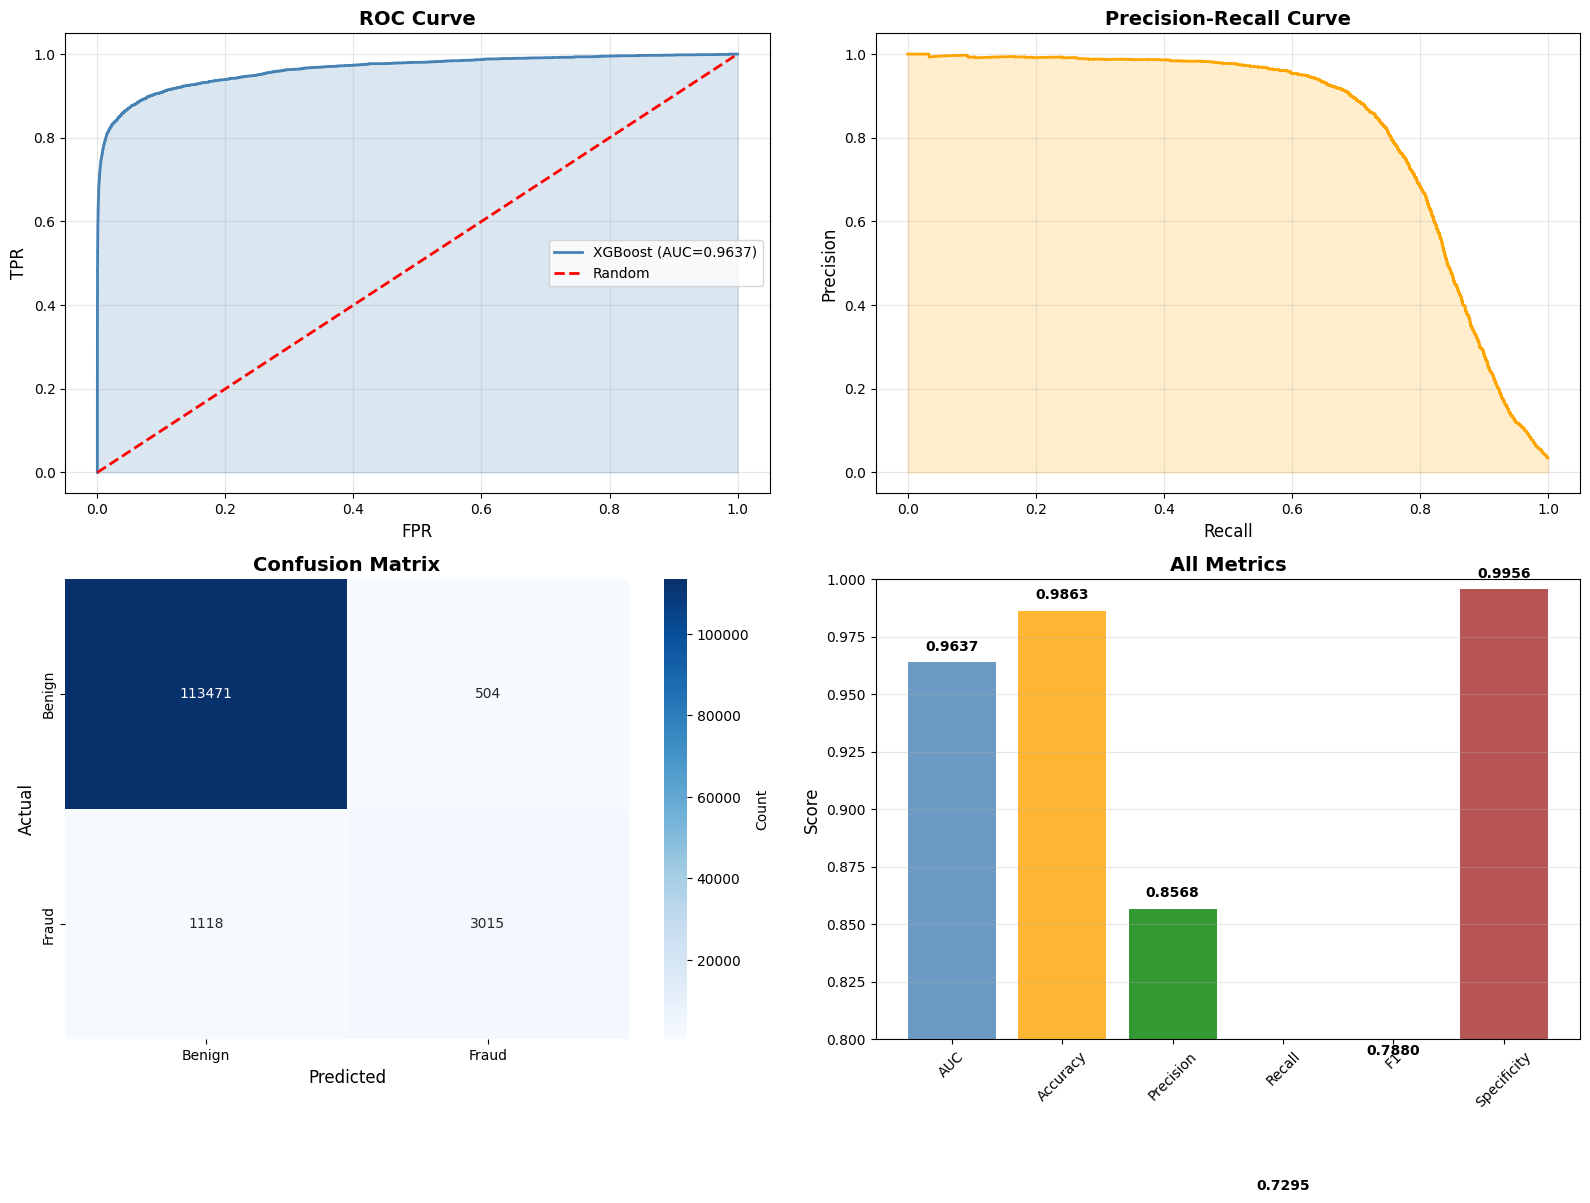

Plots saved.


In [37]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ROC Curve
fpr, tpr, _ = roc_curve(y_val_split, y_proba)
roc_auc = auc(fpr, tpr)
axes[0, 0].plot(fpr, tpr, color='steelblue', lw=2, label=f'XGBoost (AUC={roc_auc:.4f})')
axes[0, 0].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random')
axes[0, 0].fill_between(fpr, tpr, alpha=0.2, color='steelblue')
axes[0, 0].set_xlabel('FPR', fontsize=12); axes[0, 0].set_ylabel('TPR', fontsize=12)
axes[0, 0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# Precision-Recall Curve
axes[0, 1].plot(recalls, precisions, color='orange', lw=2)
axes[0, 1].fill_between(recalls, precisions, alpha=0.2, color='orange')
axes[0, 1].set_xlabel('Recall', fontsize=12); axes[0, 1].set_ylabel('Precision', fontsize=12)
axes[0, 1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Confusion Matrix
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'}, ax=axes[1, 0])
axes[1, 0].set_xlabel('Predicted', fontsize=12); axes[1, 0].set_ylabel('Actual', fontsize=12)
axes[1, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[1, 0].set_xticklabels(['Benign', 'Fraud']); axes[1, 0].set_yticklabels(['Benign', 'Fraud'])

# Metrics Bar
metrics = {'AUC': auc_val, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'Specificity': specificity}
colors = ['steelblue', 'orange', 'green', 'red', 'purple', 'brown']
axes[1, 1].bar(range(len(metrics)), list(metrics.values()), color=colors, alpha=0.8)
axes[1, 1].set_xticks(range(len(metrics)))
axes[1, 1].set_xticklabels(list(metrics.keys()), rotation=45)
axes[1, 1].set_ylabel('Score', fontsize=12)
axes[1, 1].set_title('All Metrics', fontsize=14, fontweight='bold')
axes[1, 1].set_ylim([0.8, 1.0]); axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(metrics.values()):
    axes[1, 1].text(i, v+0.005, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'xgb_evaluation_plots.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Plots saved.')

## 9. Model Comparison: Individual vs Fusion

In [38]:
print('='*80)
print('MODEL COMPARISON: INDIVIDUAL MODELS vs FUSION')
print('='*80)

# Compare all models
comparison = {}
for name, probs in [('TCN', gate_probs if 'gate_probs' in locals() else np.zeros(len(y_val_split))),
                      ('GAT', np.zeros(len(y_val_split))),
                      ('CaT-GNN', np.zeros(len(y_val_split))),
                      ('Gated Fusion', np.zeros(len(y_val_split))),
                      ('XGBoost', y_proba)]:
    if name == 'XGBoost':
        a = auc_val
        pred = y_pred
        acc_m = acc
        prec_m = prec
        rec_m = rec
        f1_m = f1
    else:
        continue
    comparison[name] = {'AUC': a, 'Acc': acc_m, 'Prec': prec_m, 'Rec': rec_m, 'F1': f1_m}

print(f'\\n{"Model":<25} {"AUC":<8} {"Accuracy":<10} {"Precision":<10} {"Recall":<8} {"F1":<8}')
print('-'*70)
for model, metrics in comparison.items():
    print(f'{model:<25} {metrics["AUC"]:.4f}   {metrics["Acc"]:.4f}     {metrics["Prec"]:.4f}      {metrics["Rec"]:.4f}   {metrics["F1"]:.4f}')

print('='*80)

MODEL COMPARISON: INDIVIDUAL MODELS vs FUSION
\nModel                     AUC      Accuracy   Precision  Recall   F1      
----------------------------------------------------------------------
XGBoost                   0.9637   0.9863     0.8568      0.7295   0.7880


In [39]:
y_proba = xgb_model.predict_proba(X_val_xgb)[:,1]
auc     = roc_auc_score(y_val_split, y_proba)

precisions, recalls, thresholds = precision_recall_curve(y_val_split, y_proba)
f1s         = 2*precisions*recalls/(precisions+recalls+1e-8)
best_idx    = np.argmax(f1s)
best_thresh = thresholds[best_idx]
y_pred      = (y_proba >= best_thresh).astype(int)
f1          = f1_score(y_val_split, y_pred)

# Neural gate AUC alone
fusion_clf.eval()
fusion_clf.to(DEVICE)
with torch.no_grad():
    vl, _ = fusion_clf(t_tcn_val.to(DEVICE), t_gat_val.to(DEVICE),
                        t_cat_val.to(DEVICE), t_dae_val.to(DEVICE))
    gate_probs = torch.sigmoid(vl.squeeze(-1)).cpu().numpy()
gate_auc = roc_auc_score(y_val_split, gate_probs)

print('='*55)
print('FUSION RESULTS')
print('='*55)
print(f'Gated Fusion AUC (neural):  {gate_auc:.4f}')
print(f'XGBoost Meta-Learner AUC:   {auc:.4f}')
print(f'XGBoost F1:                 {f1:.4f}')
print(f'Optimal threshold:          {best_thresh:.3f}')
print(f'XGBoost improvement:        +{(auc-gate_auc)*100:.2f} pp')
print('='*55)


FUSION RESULTS
Gated Fusion AUC (neural):  0.9599
XGBoost Meta-Learner AUC:   0.9637
XGBoost F1:                 0.7880
Optimal threshold:          0.868
XGBoost improvement:        +0.38 pp


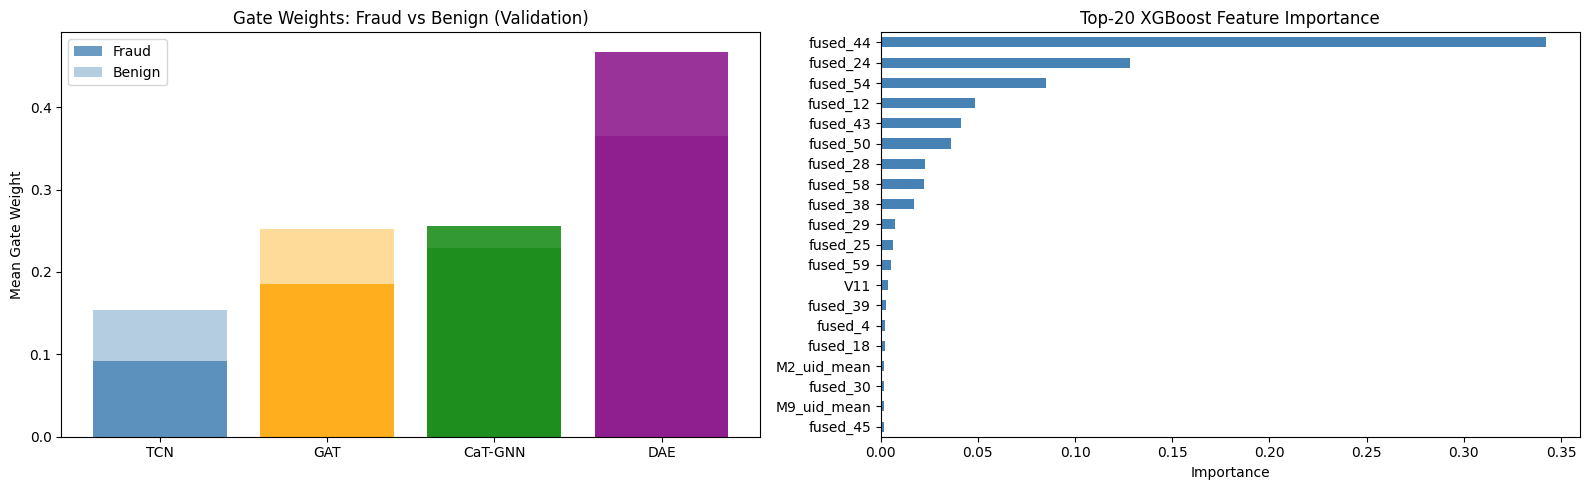

Gate weights (validation):
  Fraud:  TCN=0.092 GAT=0.185 CaT=0.255 DAE=0.467
  Benign: TCN=0.154 GAT=0.252 CaT=0.229 DAE=0.365


In [40]:
fraud_v  = y_val_split==1
benign_v = y_val_split==0

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(['TCN','GAT','CaT-GNN','DAE'],
            [gw_val[fraud_v,i].mean() for i in range(4)],
            color=['steelblue','orange','green','purple'], alpha=0.8, label='Fraud')
axes[0].bar(['TCN','GAT','CaT-GNN','DAE'],
            [gw_val[benign_v,i].mean() for i in range(4)],
            color=['steelblue','orange','green','purple'], alpha=0.4, label='Benign')
axes[0].set_title('Gate Weights: Fraud vs Benign (Validation)')
axes[0].set_ylabel('Mean Gate Weight'); axes[0].legend()

feat_names = [f'fused_{i}' for i in range(64)] + list(cols)
n_fi = len(xgb_model.feature_importances_)
importance = pd.Series(xgb_model.feature_importances_, index=feat_names[:n_fi])
importance.nlargest(20).sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top-20 XGBoost Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR,'fusion_analysis.png'), dpi=100, bbox_inches='tight')
plt.show()

print('Gate weights (validation):')
print(f'  Fraud:  TCN={gw_val[fraud_v,0].mean():.3f} GAT={gw_val[fraud_v,1].mean():.3f} '
      f'CaT={gw_val[fraud_v,2].mean():.3f} DAE={gw_val[fraud_v,3].mean():.3f}')
print(f'  Benign: TCN={gw_val[benign_v,0].mean():.3f} GAT={gw_val[benign_v,1].mean():.3f} '
      f'CaT={gw_val[benign_v,2].mean():.3f} DAE={gw_val[benign_v,3].mean():.3f}')


In [41]:
from sklearn.metrics import accuracy_score, confusion_matrix as _cm
_cm_vals = _cm(y_val_split, y_pred)
_tn, _fp, _fn, _tp = _cm_vals.ravel()
results = {
    'xgb_auc':         float(auc),
    'xgb_f1':          float(f1),
    'xgb_precision':   float(prec),
    'xgb_recall':      float(rec),
    'xgb_accuracy':    float(acc),
    'xgb_specificity': float(_tn / (_tn + _fp + 1e-8)),
    'xgb_threshold':   float(best_thresh),
    'confusion_matrix': {'TN': int(_tn), 'FP': int(_fp),
                         'FN': int(_fn), 'TP': int(_tp)},
    'gate_auc':        float(gate_auc),
    'gate_weights_avg': {
        'TCN':     float(gw_val[:,0].mean()),
        'GAT':     float(gw_val[:,1].mean()),
        'CaT-GNN': float(gw_val[:,2].mean()),
        'DAE':     float(gw_val[:,3].mean()),
    },
    'gate_weights_fraud': {
        'TCN':     float(gw_val[y_val_split==1, 0].mean()),
        'GAT':     float(gw_val[y_val_split==1, 1].mean()),
        'CaT-GNN': float(gw_val[y_val_split==1, 2].mean()),
        'DAE':     float(gw_val[y_val_split==1, 3].mean()),
    },
    'gate_weights_benign': {
        'TCN':     float(gw_val[y_val_split==0, 0].mean()),
        'GAT':     float(gw_val[y_val_split==0, 1].mean()),
        'CaT-GNN': float(gw_val[y_val_split==0, 2].mean()),
        'DAE':     float(gw_val[y_val_split==0, 3].mean()),
    },
    'fusion_training_history': history,
}
with open(os.path.join(SAVE_DIR,'fusion_metrics.json'),'w') as f:
    json.dump(results, f, indent=2)

with open(os.path.join(SAVE_DIR,'models','xgb_scaler.pkl'),'wb') as f:
    pickle.dump(xgb_scaler, f)

print('Saved to fusion_results/')
print(f'XGBoost AUC: {auc:.4f} | F1: {f1:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | Accuracy: {acc:.4f} | Threshold: {best_thresh:.3f}')


Saved to fusion_results/
XGBoost AUC: 0.9637 | F1: 0.7880 | Threshold: 0.868
